In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 解决负号 '-' 显示为方块的问题


In [41]:
df=pd.read_csv('exam_pass.csv')


In [42]:
df['学习方式']=df['学习方式'].map({'看书':0,'做题':1})

In [43]:
y=df['通过考试']
X=df.drop('通过考试',axis=1)

In [44]:
X.head()

,学习时长,学习方式
0,1.5,0
1,2.0,0
2,2.5,0
3,3.0,0
4,3.5,0


In [45]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
scaler=StandardScaler()

In [47]:
X_train_scaled=scaler.fit_transform(X_train)

In [48]:
X_test_scaled=scaler.transform(X_test)

In [49]:
model=SVC(kernel='linear', C=1, gamma='auto')

In [50]:
model.fit(X_train_scaled,y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [57]:
print('线性核预测准确度：' ,accuracy_score(y_test, model.predict(X_test_scaled))*100,'%')

线性核预测准确度： 66.66666666666666 %


In [58]:
model=SVC(kernel='rbf', C=1, gamma='auto')

In [59]:
model.fit(X_train_scaled,y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [60]:
print('高斯核预测准确度：' ,accuracy_score(y_test, model.predict(X_test_scaled))*100,'%')

高斯核预测准确度： 66.66666666666666 %


In [61]:
sns.set_style("whitegrid")

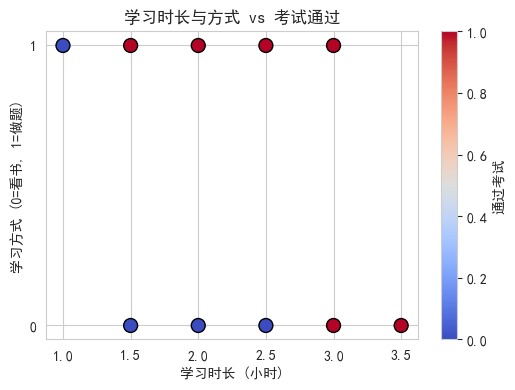

In [65]:
# 画图：横轴=学习时长，纵轴=学习方式，颜色=是否通过考试
plt.figure(figsize=(6, 4))

# scatter 参数：x数据, y数据, c=颜色标签, cmap=颜色映射
plt.scatter(df['学习时长'], df['学习方式'], c=df['通过考试'], cmap='coolwarm', s=100, edgecolors='black')

plt.xlabel('学习时长 (小时)')
plt.ylabel('学习方式 (0=看书, 1=做题)')
plt.title('学习时长与方式 vs 考试通过')
plt.colorbar(label='通过考试')  # 颜色条说明

# 让y轴只显示0和1两个刻度
plt.yticks([0, 1])

plt.show()